Downloading/Loading fully trained Faster R-CNN model... (This may take a minute)
Model loaded successfully!
Scanning image for objects...


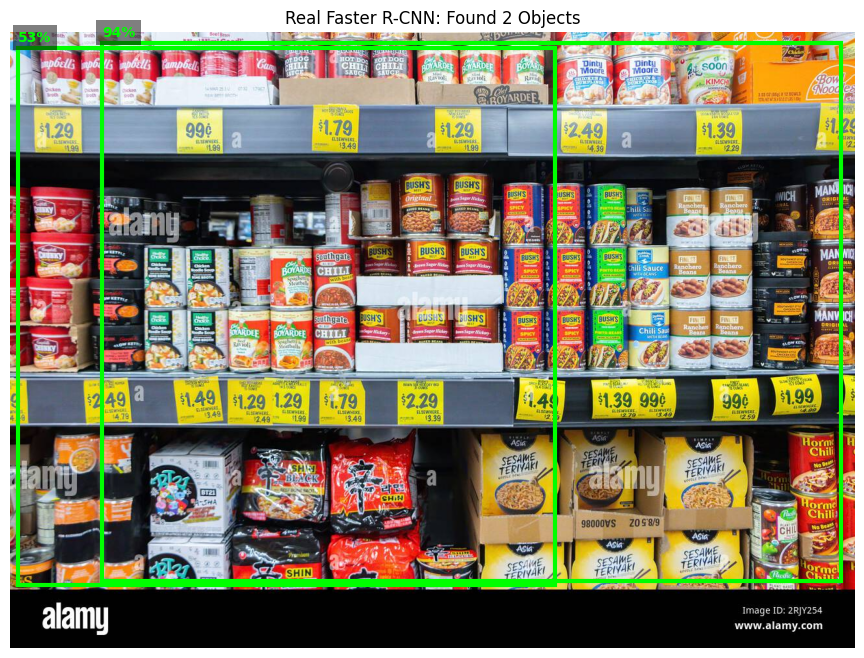

Success! Dynamically detected 2 objects in your image.
Saved visualization to: real_detection_output.jpg


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("Downloading/Loading fully trained Faster R-CNN model... (This may take a minute)")

# ---------------------------------------------------------
# 1. MODEL SETUP
# ---------------------------------------------------------
# Load a pre-trained Faster R-CNN model from TF Hub.
# This model uses a ResNet50 backbone and was trained on the COCO dataset.
MODEL_URL = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
detector = hub.load(MODEL_URL)
print("Model loaded successfully!")

# ---------------------------------------------------------
# 2. IMAGE PREPROCESSING
# ---------------------------------------------------------
file_path = "/content/Retail.jpg" # Target image for detection

if not os.path.exists(file_path):
    print(f"Error: '{file_path}' not found. Please upload or place the image in the directory.")
else:
    # Read the image using OpenCV
    img = cv2.imread(file_path)

    # OpenCV loads images in BGR format by default.
    # TensorFlow models expect standard RGB format.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # The model expects a batch of images as a tensor.
    # Convert to tensor and add a batch dimension: [1, Height, Width, 3]
    img_tensor = tf.convert_to_tensor(img_rgb, dtype=tf.uint8)
    img_tensor = tf.expand_dims(img_tensor, 0)

    # ---------------------------------------------------------
# 3. INFERENCE
    # ---------------------------------------------------------
    print("Scanning image for objects...")

    # Run the image through the network.
    # The TF Hub model automatically handles the RPN, ROI Align, and NMS internally.
    results = detector(img_tensor)

    # Extract bounding boxes and confidence scores from the results dictionary.
    # Index [0] is used because we only passed a single image (batch size 1).
    boxes = results["detection_boxes"][0].numpy()
    scores = results["detection_scores"][0].numpy()

    # ---------------------------------------------------------
# 4. VISUALIZATION & EXPORT
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)

    # Get image dimensions to scale the normalized bounding box coordinates
    h, w, _ = img_rgb.shape

    # Set a confidence threshold to filter out weak/background predictions
    min_confidence = 0.50
    detections = 0

    for i in range(len(scores)):
        if scores[i] >= min_confidence:
            detections += 1

            # The model outputs normalized coordinates between 0 and 1
            # Format: [ymin, xmin, ymax, xmax]
            ymin, xmin, ymax, xmax = boxes[i]

            # Convert normalized coordinates to absolute pixel coordinates
            y1, x1 = int(ymin * h), int(xmin * w)
            y2, x2 = int(ymax * h), int(xmax * w)

            # Draw the bounding box (Green)
            plt.gca().add_patch(
                plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='#00ff00', linewidth=3)
            )

            # Draw the confidence score label
            score_text = f"{scores[i]*100:.0f}%"
            plt.text(
                x1, y1 - 10, score_text, color='#00ff00', fontsize=10, weight='bold',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none')
            )

    # Render and save the final image
    plt.title(f"Real Faster R-CNN: Found {detections} Objects")
    plt.axis('off')

    output_filename = "real_detection_output.jpg"
    plt.savefig(output_filename, bbox_inches='tight')
    plt.show()

    print(f"Success! Dynamically detected {detections} objects in your image.")
    print(f"Saved visualization to: {output_filename}")